# Granularity Experiment

Notebook flow:
1. Oversampling comparison (binary) — pick best sampler
2. TF-IDF cosine similarity intra-game — identify natural class merge candidates
3. Generate src/label_schemes.py from empirical findings
4. Incremental granularity experiment — all n_classes, all models, full metrics
5. Sweet spot plots

## 0. Imports & CONFIG

In [25]:
# Standard imports 
import warnings, time, json, textwrap
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.loaders import load_wot, load_dota
from src.pipelines import build_pipe
from src.scoring import cv_score, append_registry

CONFIG = {
    'seed': 7524,
    'cv_folds': 5,
    'text_col': 'clean_message',
    'label_col': 'label',
    'registry_path': Path('../../data/results/results_registry.csv'),
    'label_schemes_path': Path('../../src/label_schemes.py'),
}

# reproducibility 
seed = CONFIG['seed']
cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=seed)
np.random.seed(seed)

# classes 
WOT_CLASSES  = {0:'Non-Toxic', 1:'Insults', 2:'Other Offensive Texts', 3:'Hate and Harassment', 4:'Threats', 5:'Extremism'}
DOTA_CLASSES = {0:'Non-Toxic', 1:'Ego', 2:'Aggression', 3:'Impolite'}
print('CONFIG loaded.')

CONFIG loaded.


**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

**Outputs produced:**
- `src/label_schemes.py` - empirically derived merge dicts for all granularity levels
- `data/results/granularity_sweet_spot.png` - multi-metric line plot
- `data/results/intra_game_cosine_similarity.png` - class vocabulary overlap heatmap
- Rows appended to `data/results/results_registry.csv`

## 1. Oversampling Comparison (Binary)

In [26]:
# Compare all 4 oversamplers at binary level to pick the best before running
# the full multiclass experiment. Binary is fastest — minimises wall time here.
wot_train_raw  = load_wot('train')
wot_val_raw    = load_wot('val')
dota_train_raw = load_dota('train')
dota_val_raw   = load_dota('val')

# Binarise for oversampler comparison: label > 0 → 1
X_wot_train  = wot_train_raw[CONFIG['text_col']]
y_wot_bin = (wot_train_raw[CONFIG['label_col']].astype(int) > 0).astype(int)

X_dota_train = dota_train_raw[CONFIG['text_col']]
y_dota_bin = (dota_train_raw[CONFIG['label_col']].astype(int) > 0).astype(int)

# list of oversamplers 
OVERSAMPLERS = {
    'RandomOverSampler': RandomOverSampler(random_state=seed),
    'SMOTE':             SMOTE(random_state=seed),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=seed),
    'ADASYN':            ADASYN(random_state=seed),
}

# initiate logistic regressuin
ref_clf   = LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=1)

# list for results
os_results = []

for game, X_tr, y_tr in [('WoT', X_wot_train, y_wot_bin),
                           ('Dota', X_dota_train, y_dota_bin)]:
    print(f'=== {game} ===')
    # loop to check cross-validation scores for each game
    for os_name, sampler in OVERSAMPLERS.items():
        pipe   = build_pipe(clone(ref_clf), oversampler=sampler)
        scores = cv_score(pipe, X_tr, y_tr, cv=cv)
        print(f' {os_name:<20} cv_f1={scores["cv_f1"]:.4f} '
              f'recall={scores["cv_recall"]:.4f} '
              f'precision={scores["cv_precision"]:.4f}')
        os_results.append({'game': game, 'oversampler': os_name, **scores})

# appents to os_results and create a dataframe 
os_df = pd.DataFrame(os_results)

# identify best oversampling for each game
print('\n--- Best per game ---')
for game in ['WoT', 'Dota']:
    best = os_df[os_df['game']==game].sort_values('cv_f1', ascending=False).iloc[0]
    print(f'{game}: {best["oversampler"]} (cv_f1={best["cv_f1"]:.4f})')

=== WoT ===
 RandomOverSampler    cv_f1=0.7495 recall=0.7417 precision=0.7577
 SMOTE                cv_f1=0.7421 recall=0.7369 precision=0.7477
 BorderlineSMOTE      cv_f1=0.7338 recall=0.7223 precision=0.7458
 ADASYN               cv_f1=0.6121 recall=0.7834 precision=0.5288
=== Dota ===
 RandomOverSampler    cv_f1=0.7864 recall=0.7345 precision=0.8467
 SMOTE                cv_f1=0.7858 recall=0.7309 precision=0.8500
 BorderlineSMOTE      cv_f1=0.7726 recall=0.7390 precision=0.8101
 ADASYN               cv_f1=0.7745 recall=0.7447 precision=0.8073

--- Best per game ---
WoT: RandomOverSampler (cv_f1=0.7495)
Dota: RandomOverSampler (cv_f1=0.7864)


The gains are very marginal. So instead of using artifical oversamplers, it is safer to use `RandomOversampler`. 

## 2. TF-IDF Cosine Similarity — Intra-Game Class Clustering

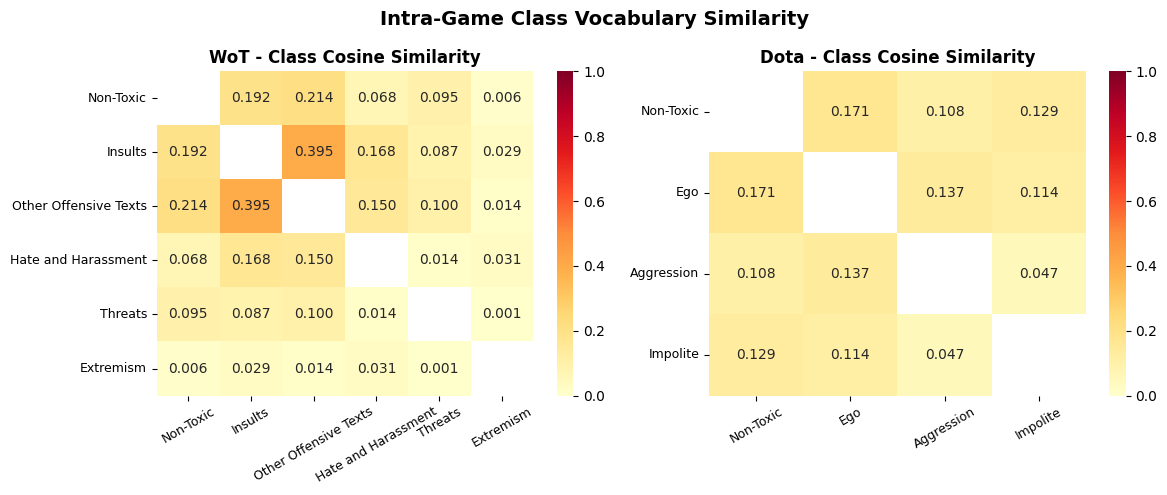


=== WoT merge candidates (sorted by similarity, excluding diagonal) ===
  Non-Toxic ↔ Insults: 0.192
  Non-Toxic ↔ Other Offensive Texts: 0.214
  Non-Toxic ↔ Hate and Harassment: 0.068
  Non-Toxic ↔ Threats: 0.095
  Non-Toxic ↔ Extremism: 0.006
  Insults ↔ Other Offensive Texts: 0.395
  Insults ↔ Hate and Harassment: 0.168
  Insults ↔ Threats: 0.087
  Insults ↔ Extremism: 0.029
  Other Offensive Texts ↔ Hate and Harassment: 0.150
  Other Offensive Texts ↔ Threats: 0.100
  Other Offensive Texts ↔ Extremism: 0.014
  Hate and Harassment ↔ Threats: 0.014
  Hate and Harassment ↔ Extremism: 0.031
  Threats ↔ Extremism: 0.001

=== Dota merge candidates ===
  Non-Toxic ↔ Ego: 0.171
  Non-Toxic ↔ Aggression: 0.108
  Non-Toxic ↔ Impolite: 0.129
  Ego ↔ Aggression: 0.137
  Ego ↔ Impolite: 0.114
  Aggression ↔ Impolite: 0.047


In [27]:
# Compute TF-IDF centroid per class and cosine similarity matrix for each game.
# High similarity between two classes = they share vocabulary = merge candidates.
# This drives the label scheme design - not assumptions.

# function to compute average vector for each class 
def class_centroids(texts: pd.Series, labels: pd.Series, n_classes: int) -> np.ndarray:
    """Fit TF-IDF on texts, return L2-normalised centroid matrix (n_classes × vocab)."""
    # tf-idf 
    tfidf = TfidfVectorizer(ngram_range=(1,2), 
                            min_df=1, 
                            max_df=0.95,
                            sublinear_tf=True, 
                            norm='l2')
    # fit on text 
    X = tfidf.fit_transform(texts)
    centroids = []
    for c in range(n_classes):
        mask = (labels.astype(int) == c).values
        centroids.append(np.asarray(X[mask].mean(axis=0)))
    return normalize(np.vstack(centroids))

# get centroids 
# world of tanks
wot_centroids  = class_centroids(wot_train_raw[CONFIG['text_col']],
                                   wot_train_raw[CONFIG['label_col']], 6)

# dota 
dota_centroids = class_centroids(dota_train_raw[CONFIG['text_col']],
                                   dota_train_raw[CONFIG['label_col']], 4)

# apply cosine similary on tfidf 
wot_sim  = cosine_similarity(wot_centroids)
dota_sim = cosine_similarity(dota_centroids)

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# names
wot_names  = list(WOT_CLASSES.values())
dota_names = list(DOTA_CLASSES.values())

for ax, sim, names, title in [
    (axes[0], wot_sim,  wot_names,  'WoT - Class Cosine Similarity'),
    (axes[1], dota_sim, dota_names, 'Dota - Class Cosine Similarity'),
]:
    mask = np.eye(len(names), dtype=bool)   # hide diagonal (self-similarity = 1.0)
    sim_display = sim.copy()
    sim_display[mask] = np.nan

    # heatmap
    sns.heatmap(sim_display, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=names, yticklabels=names, ax=ax, vmin=0, vmax=1)
    
    # design 
    # title for each plot
    ax.set_title(title, fontweight='bold', fontsize=12)

    # tick parameters 
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

# global plot for both visualizations 
plt.suptitle('Intra-Game Class Vocabulary Similarity', fontweight='bold', fontsize=14)

# save the evidence 
Path('../../data/results').mkdir(parents=True, exist_ok=True)
plt.savefig('../../data/results/intra_game_cosine_similarity.png', dpi=150, bbox_inches='tight')

# show the plot 
plt.tight_layout()
plt.show()

# Print ranked merge candidates
print('\n=== WoT merge candidates (sorted by similarity, excluding diagonal) ===')
for i in range(6):
    for j in range(i+1, 6):
        print(f'  {wot_names[i]} \u2194 {wot_names[j]}: {wot_sim[i,j]:.3f}')

print('\n=== Dota merge candidates ===')
for i in range(4):
    for j in range(i+1, 4):
        print(f'  {dota_names[i]} \u2194 {dota_names[j]}: {dota_sim[i,j]:.3f}')

Within Dota, we cannot really merge anything. However, within World of Tanks we can combine `Insults` and `Other Offensive Text` due to relatively strong similarity. 

## 3. Define Label Schemes from Empirical Findings

In [28]:
# Incremental severity-based splits — each step separates the next hardest class.
# Build from binary upward: merge similar first, split severe last.
# Labels must be 0-indexed and contiguous.

# n=2: binary
WOT_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}

# n=3: Non-Toxic / Insults+OtherOffensive / Hate+Threats+Extremism
WOT_SCHEME_3 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}

# n=4: Non-Toxic / Insults+OtherOffensive / Hate / Threats+Extremism
WOT_SCHEME_4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3}

# n=5: Non-Toxic / Insults+OtherOffensive / Hate / Threats / Extremism
WOT_SCHEME_5 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 4}

# n=6: identity
WOT_SCHEME_6 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

# Dota: no merge candidates found, but we can iterate just to experiment
# binary
DOTA_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1}

# n=3: Non-Toxic / Ego / Agression+Impolite
DOTA_SCHEME_3 = {0: 0, 1: 1, 2: 2, 3: 2}

# n=4: Non-Toxic / Ego / Agression / Impolite
DOTA_SCHEME_4 = {0: 0, 1: 1, 2: 2, 3: 3}

WOT_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Insults/Other Offensive', 'Hate+Threats+Extremism'],
    4: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats+Extremism'],
    5: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats', 'Extremism'],
    6: list(WOT_CLASSES.values()),
}

DOTA_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Ego', 'Aggression+Impolite'],
    4: ['Non-Toxic', 'Ego', 'Aggression', 'Impolite'],
}

WOT_SCHEMES  = {2: WOT_SCHEME_2, 3: WOT_SCHEME_3, 4: WOT_SCHEME_4,
                5: WOT_SCHEME_5, 6: WOT_SCHEME_6}
DOTA_SCHEMES = {2: DOTA_SCHEME_2, 3: DOTA_SCHEME_3, 4: DOTA_SCHEME_4}

print('Schemes defined.')
print('WoT schemes:', list(WOT_SCHEMES.keys()))
print('Dota schemes:', list(DOTA_SCHEMES.keys()))

Schemes defined.
WoT schemes: [2, 3, 4, 5, 6]
Dota schemes: [2, 3, 4]


## 4. Write src/label_schemes.py

In [29]:
# Generate src/label_schemes.py as a product of this notebook's analysis.
# This file is the empirical output
label_schemes_content = textwrap.dedent(f"""\
    # Auto-generated by notebooks/01_granularity_experiment.ipynb
    # Based on TF-IDF cosine similarity analysis - edit Section 3 of that notebook to update.

    WOT_SCHEMES = {WOT_SCHEMES!r}

    DOTA_SCHEMES = {DOTA_SCHEMES!r}

    WOT_CLASS_NAMES = {WOT_CLASS_NAMES!r}

    DOTA_CLASS_NAMES = {DOTA_CLASS_NAMES!r}
    """)

CONFIG['label_schemes_path'].write_text(label_schemes_content, encoding='utf-8')
print(f'Written: {CONFIG["label_schemes_path"]}')
print('Contents preview:')
print(label_schemes_content[:400])

Written: ..\..\src\label_schemes.py
Contents preview:
# Auto-generated by notebooks/01_granularity_experiment.ipynb
# Based on TF-IDF cosine similarity analysis - edit Section 3 of that notebook to update.

WOT_SCHEMES = {2: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}, 3: {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}, 4: {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3}, 5: {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 4}, 6: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}}

DOTA_SCHEMES = {2: {0: 0, 


## 5. Incremental Granularity Experiment

In [30]:
# run all 3 models at every granularity level for each game
def run_granularity_track(game, raw_train, schemes, class_names_map, registry_path):
    results = []

    for n_classes, scheme in schemes.items():
        # apply scheme inline
        train = raw_train.copy()
        train[CONFIG['label_col']] = train[CONFIG['label_col']].astype(int).map(scheme)
        X_train = train[CONFIG['text_col']]
        y_train = train[CONFIG['label_col']]

        classifiers = {
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=seed),
            'Naive Bayes': MultinomialNB(),
            'LinearSVC': LinearSVC(C=1.0, max_iter=2000, tol=1e-3, random_state=seed),
        }

        best_f1, best_name = -1, None
        for clf_name, clf in classifiers.items():
            pipe = build_pipe(clone(clf), oversampler=RandomOverSampler(random_state=seed))
            scores = cv_score(pipe, X_train, y_train, cv=cv)

            print(f' {game} n={n_classes} {clf_name:<22} '
                  f'f1={scores["cv_f1"]:.4f} '
                  f'rec={scores["cv_recall"]:.4f} '
                  f'prec={scores["cv_precision"]:.4f}')

            if scores['cv_f1'] > best_f1:
                best_f1, best_name = scores['cv_f1'], clf_name

            append_registry({
                'experiment': 'granularity_per_dataset',
                'train_game': game,
                'test_game': game,
                'n_classes': n_classes,
                'label_scheme': 'empirical',
                'model': clf_name,
                **scores,
                'test_f1': None,
                'test_recall': None,
                'test_precision': None,
                'test_auc': None,
                'per_class_recall': None,
                'ood_f1': None,
                'ood_recall': None,
                'ood_precision': None,
                'ood_auc': None,
                'anomaly_auroc': None,
                'notes': '',
            }, path=registry_path)

        results.append({'game': game, 'n_classes': n_classes,
                        'best_model': best_name, 'best_cv_f1': round(best_f1, 4)})
        print(f' best: {best_name} ({best_f1:.4f})\n')

    return pd.DataFrame(results)


print('=== WoT incremental ===')
wot_results = run_granularity_track('WoT', wot_train_raw, WOT_SCHEMES, WOT_CLASS_NAMES,
                                    CONFIG['registry_path'])

print('\n=== Dota incremental ===')
dota_results = run_granularity_track('Dota', dota_train_raw, DOTA_SCHEMES, DOTA_CLASS_NAMES,
                                     CONFIG['registry_path'])

print('\nWoT:')
print(wot_results.to_string(index=False))
print('\nDota:')
print(dota_results.to_string(index=False))

=== WoT incremental ===
 WoT n=2 Logistic Regression    f1=0.7495 rec=0.7417 prec=0.7577
 WoT n=2 Naive Bayes            f1=0.6966 rec=0.7818 prec=0.6283
 WoT n=2 LinearSVC              f1=0.7455 rec=0.7255 prec=0.7669
 best: Logistic Regression (0.7495)

 WoT n=3 Logistic Regression    f1=0.6592 rec=0.6887 prec=0.6445
 WoT n=3 Naive Bayes            f1=0.5839 rec=0.7037 prec=0.5559
 WoT n=3 LinearSVC              f1=0.6540 rec=0.6827 prec=0.6402
 best: Logistic Regression (0.6592)

 WoT n=4 Logistic Regression    f1=0.5725 rec=0.6415 prec=0.5604
 WoT n=4 Naive Bayes            f1=0.4625 rec=0.6750 prec=0.4323
 WoT n=4 LinearSVC              f1=0.5612 rec=0.6165 prec=0.5585
 best: Logistic Regression (0.5725)

 WoT n=5 Logistic Regression    f1=0.5100 rec=0.5697 prec=0.5259
 WoT n=5 Naive Bayes            f1=0.3886 rec=0.6292 prec=0.3566
 WoT n=5 LinearSVC              f1=0.5012 rec=0.5473 prec=0.5244
 best: Logistic Regression (0.5100)

 WoT n=6 Logistic Regression    f1=0.4842 rec=0.

## 6. Sweet Spot Plots

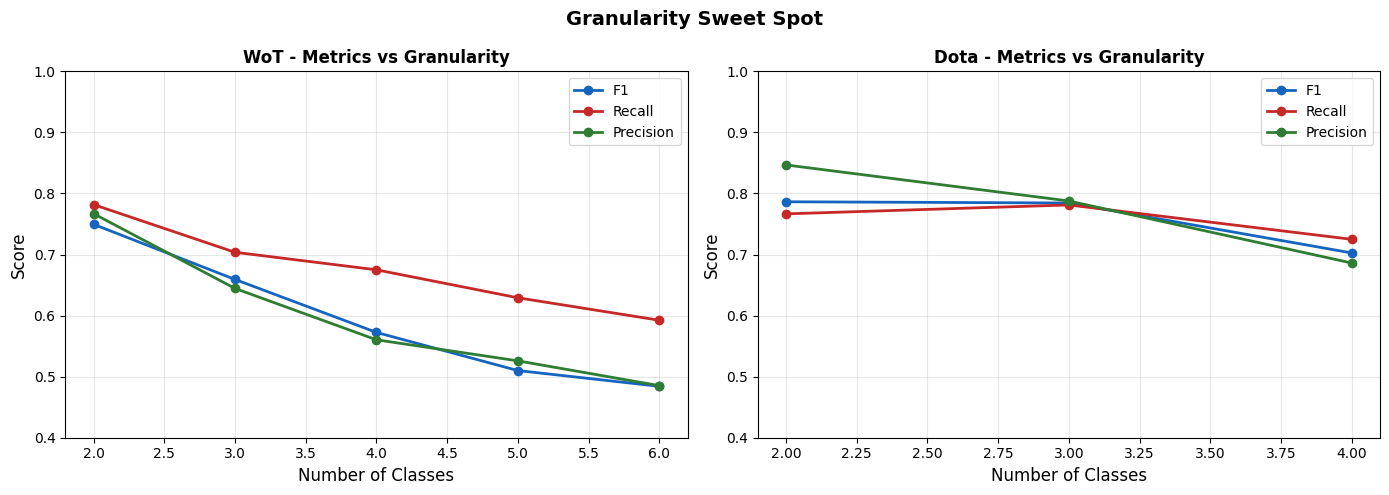

In [31]:
# sweet spot plot: F1, recall, precision vs n_classes per game
# peak before decline = optimal granularity for this feature set
registry = pd.read_csv(CONFIG['registry_path'])
gran = registry[registry['experiment'] == 'granularity_per_dataset']

metrics = [
    ('cv_f1', 'F1', '#1565C0'),
    ('cv_recall', 'Recall', '#C62828'),
    ('cv_precision', 'Precision', '#2E7D32'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, game in zip(axes, ['WoT', 'Dota']):
    game_df = gran[gran['train_game'] == game]
    best_per_n = (game_df.groupby('n_classes')[['cv_f1', 'cv_recall', 'cv_precision']]
                         .max().reset_index())
    for col, label, color in metrics:
        ax.plot(best_per_n['n_classes'], best_per_n[col], marker='o',
                linewidth=2, color=color, label=label)
    ax.set_xlabel('Number of Classes', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{game} - Metrics vs Granularity', fontweight='bold')
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

plt.suptitle('Granularity Sweet Spot', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../../data/results/granularity_sweet_spot.png', dpi=150, bbox_inches='tight')
plt.show()